In [1]:
# =============================================================================
# CARGAR SECRETS
# =============================================================================
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
drive_id = user_secrets.get_secret("DRIVE_SHOP_IND_KERAS")
pat = user_secrets.get_secret("GITHUB_PAT")


In [2]:
# =============================================================================
# CONEXION CON DRIVE Y RECUPERAMOS SESION DE KERAS TUNER
# =============================================================================

# ------- PARA GOOGLE COLAB ---------------
# from google.colab import drive
# path = drive.mount('/content/drive')
# print('Path to competition files:', path)

# # Crea el directorio local si no existe
# !rm -rf kt_dir
# !mkdir -p kt_dir

# # Copia el contenido desde Drive al directorio local de Colab
# # Descomprimir el zip directamente desde Drive al entorno local
# !unzip -q "/content/drive/MyDrive/Colab Notebooks/hypermodel_sessions/lab_04/kt_dir.zip" -d ./

# ------- PARA KAGGLE ---------------
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# drive_id = user_secrets.get_secret("DRIVE_KTDIR_ZIP")

# !pip install gdown
# !gdown --id {drive_id}
# !unzip -q "/kaggle/working/kt_dir.zip" -d ./

In [3]:
# =============================================================================
# CONEXION CON REPOSITORIO PARA ACCEDER A FUNCIONES Y MODULOS DEL SRC
# =============================================================================
# ------ PARA GOOGLE COLAB ----------
# from google.colab import userdata

# # Obtener el token de forma segura
# GITHUB_PAT = userdata.get('GithubPat')

# # Usar f-string para construir el comando git clone con el token
# !git clone https://{GITHUB_PAT}@github.com/Franku03/ML-jupyter-notebooks.git


# ------ PARA KAGGLE ----------
# Obtener el token y otros datos necesarios
pat = user_secrets.get_secret("GITHUB_PAT")

!git clone https://{pat}@github.com/Franku03/ml-shopping-indicator.git

Cloning into 'ml-shopping-indicator'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 44 (delta 9), reused 37 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 344.47 KiB | 5.07 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [4]:
# =============================================================================
# CARGA DE LIBRERIAS
# =============================================================================

!pip install polars pyarrow keras --upgrade
import os
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# =============================================================================
# CARGA DE DATASETS
# =============================================================================

# LOCAL
# shop_df = pd.read_csv("../datasets/train_short.csv")

# TODO: Cambiar a polars
# KAGGLE
shop_df = pd.read_csv(
    "/kaggle/working/ml-shopping-indicator/datasets/dataset shop.csv", low_memory=False
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 8.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 31.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.8 MB/s eta 0:00:00:00:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 23.0.1
    Uninstalling pyarrow-23.0.1:
      Successfully uninstalled pyarrow-23.0.1
  Attempting uninstall: polars-runtime-32
    Found existing installation: polars-runtime-32 1.35.2
    Uninstalling polars-runtime-32-1.35.2:
      Successfully uninstalled polars-runtime-32-1.35.2
  Attempting uninstall: polars
    Found existing installation: polars 1.35.2
    Uninstalling polars-1.35.2:
      Successfully uninstalled polars-1.35.2
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstal

In [5]:
shop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

A continuación se convierten las variables categóricas que están como numéricas en el dataset a tipo "category", en teoría para ayudar a que el modelo lo entienda mejor y también porque ayuda con la optimización de la memoria.

In [6]:
# PRIMER ANÁLISIS VARIABLES CATEGÓRICAS
text_categorical_cols = [
    'OperatingSystems', 
    'Browser', 
    'Region', 
    'TrafficType', 
    'Month', 
    'VisitorType'
]
# Convertir en categóricas
shop_df[text_categorical_cols] = shop_df[text_categorical_cols].astype('category')

# Verificar cambios
print("\n--- NEW DATA TYPES ---")
print(shop_df.info())

# Resumen estadístico de las columnas numéricas
print("\n--- RESUMEN ESTADÍSTICO ---")
display(shop_df.describe())


print("\n--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---")

# No incluye las booleanas
for col in text_categorical_cols:
    print(f"\nFeature: {col}")
    print(f"Total unique categories: {shop_df[col].nunique()}")
    display(shop_df[col].value_counts(dropna=False))
    print("-" * 40)


# =============================================================================
# NOTA: MANEJO DE CATEGORÍAS RARAS (RARE LABELS)
# ============================================================================= 
# Hay variables que tienen categorías con una frecuencia extremadamente baja .
# como por ejemplo browser (ej. 1 o 6 )
#
# Es crucial que solucionemos esto en nuestro Pipeline de limpieza por dos razones:
# 1. Aprendizaje: A los modelos predictivos les cuesta encontrar patrones 
#    matemáticos reales en eventos que solo han visto una vez.
# 2. Error de Train/Test Split: Si una de estas filas únicas cae aleatoriamente 
#    en el set de prueba (Test), el modelo arrojará un error porque le pediremos 
#    que prediga una categoría que nunca conoció durante el entrenamiento (Train).
#
# Próximo paso sugerido: 
# Antes de hacer el One-Hot Encoding, debemos crear una función que agrupe todas 
# las categorías con menos del 1% o 5% de representación en una sola etiqueta 
# general llamada "Otros".
# =============================================================================
#NOTA 2: Gemini me ayudó a redactar esto porque perdí mi habilidad de redacción. Gracias.


--- NEW DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  category
 12  Browser                  12330 non-null  category
 13  Region                   12330 non-nu

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000



--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---

Feature: OperatingSystems
Total unique categories: 8


OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64

----------------------------------------

Feature: Browser
Total unique categories: 13


...

----------------------------------------

Feature: Month
Total unique categories: 10


Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

----------------------------------------

Feature: VisitorType
Total unique categories: 3


VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

----------------------------------------


In [7]:
# ANÁLISIS DE VARIABLES

#Distribución de revenue
print("\n--- DISTRIBUCIÓN DE VARIABLE OBJETIVO (REVENUE) ---")
target_distribution = shop_df['Revenue'].value_counts(normalize=True) * 100
print(target_distribution)


# Matriz de correlación
print("\n--- Matriz de correlación ---")
# Solo seleccionamos las numéricas reales
numeric_cols = shop_df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = shop_df[numeric_cols].corr()

# Mapa de calor
display(correlation_matrix.style.background_gradient(cmap='coolwarm', axis=None).format("{:.2f}"))


--- DISTRIBUCIÓN DE VARIABLE OBJETIVO (REVENUE) ---
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

--- Matriz de correlación ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Administrative,1.00,0.60,0.38,0.26,0.43,0.37,-0.22,-0.32,0.10,-0.09
Administrative_Duration,0.60,1.00,0.30,0.24,0.29,0.36,-0.14,-0.21,0.07,-0.07
Informational,0.38,0.30,1.00,0.62,0.37,0.39,-0.12,-0.16,0.05,-0.05
Informational_Duration,0.26,0.24,0.62,1.00,0.28,0.35,-0.07,-0.11,0.03,-0.03
ProductRelated,0.43,0.29,0.37,0.28,1.00,0.86,-0.20,-0.29,0.06,-0.02
ProductRelated_Duration,0.37,0.36,0.39,0.35,0.86,1.00,-0.18,-0.25,0.05,-0.04
BounceRates,-0.22,-0.14,-0.12,-0.07,-0.20,-0.18,1.00,0.91,-0.12,0.07
ExitRates,-0.32,-0.21,-0.16,-0.11,-0.29,-0.25,0.91,1.00,-0.17,0.10
PageValues,0.10,0.07,0.05,0.03,0.06,0.05,-0.12,-0.17,1.00,-0.06
SpecialDay,-0.09,-0.07,-0.05,-0.03,-0.02,-0.04,0.07,0.10,-0.06,1.00


Notas rápidas del Análisis de Datos (otra vez redacción cortesía de Gemini)
Chicos, revisando los datos me di cuenta de dos cuestiones importantes:

1. El engaño del Accuracy (Desbalanceo de datos)

* El problema: Resulta que el 84.5% de la gente en este dataset NO compra. Esto significa que si armamos un modelo súper flojo que simplemente adivine "No Compra" el 100% de las veces, mágicamente sacaría un 84.5% de accuracy sin aprender absolutamente nada.

* La solución: Para llegar al 90% real, el modelo tiene que ser un genio detectando a ese 15.5% que sí compra. En el pipeline tenemos que meter SMOTE (para inventar datos sintéticos de compradores y equilibrar la balanza) o ponerle un class_weight='balanced' a la red neuronal para que le preste más atención a las compras.

2. Variables clonadas (Multicolinealidad)

* El problema: Saqué la matriz de correlación y hay variables que dicen exactamente lo mismo y solo van a confundir al modelo (y hacerlo más lento):
    * BounceRates y ExitRates se parecen en un 91%.
    * ProductRelated y el tiempo que pasan en ellas (ProductRelated_Duration) se parecen en un 86%.

* La solución: Tenemos que dropear (eliminar) una de las dos para no meterle ruido matemático al modelo. Yo sugiero (con "Yo" me refiero a Gemini) volar BounceRates y quedarnos solo con ExitRates, que es una métrica más completa.


--- COMPARATIVA DE OUTLIERS: CON VS SIN ---


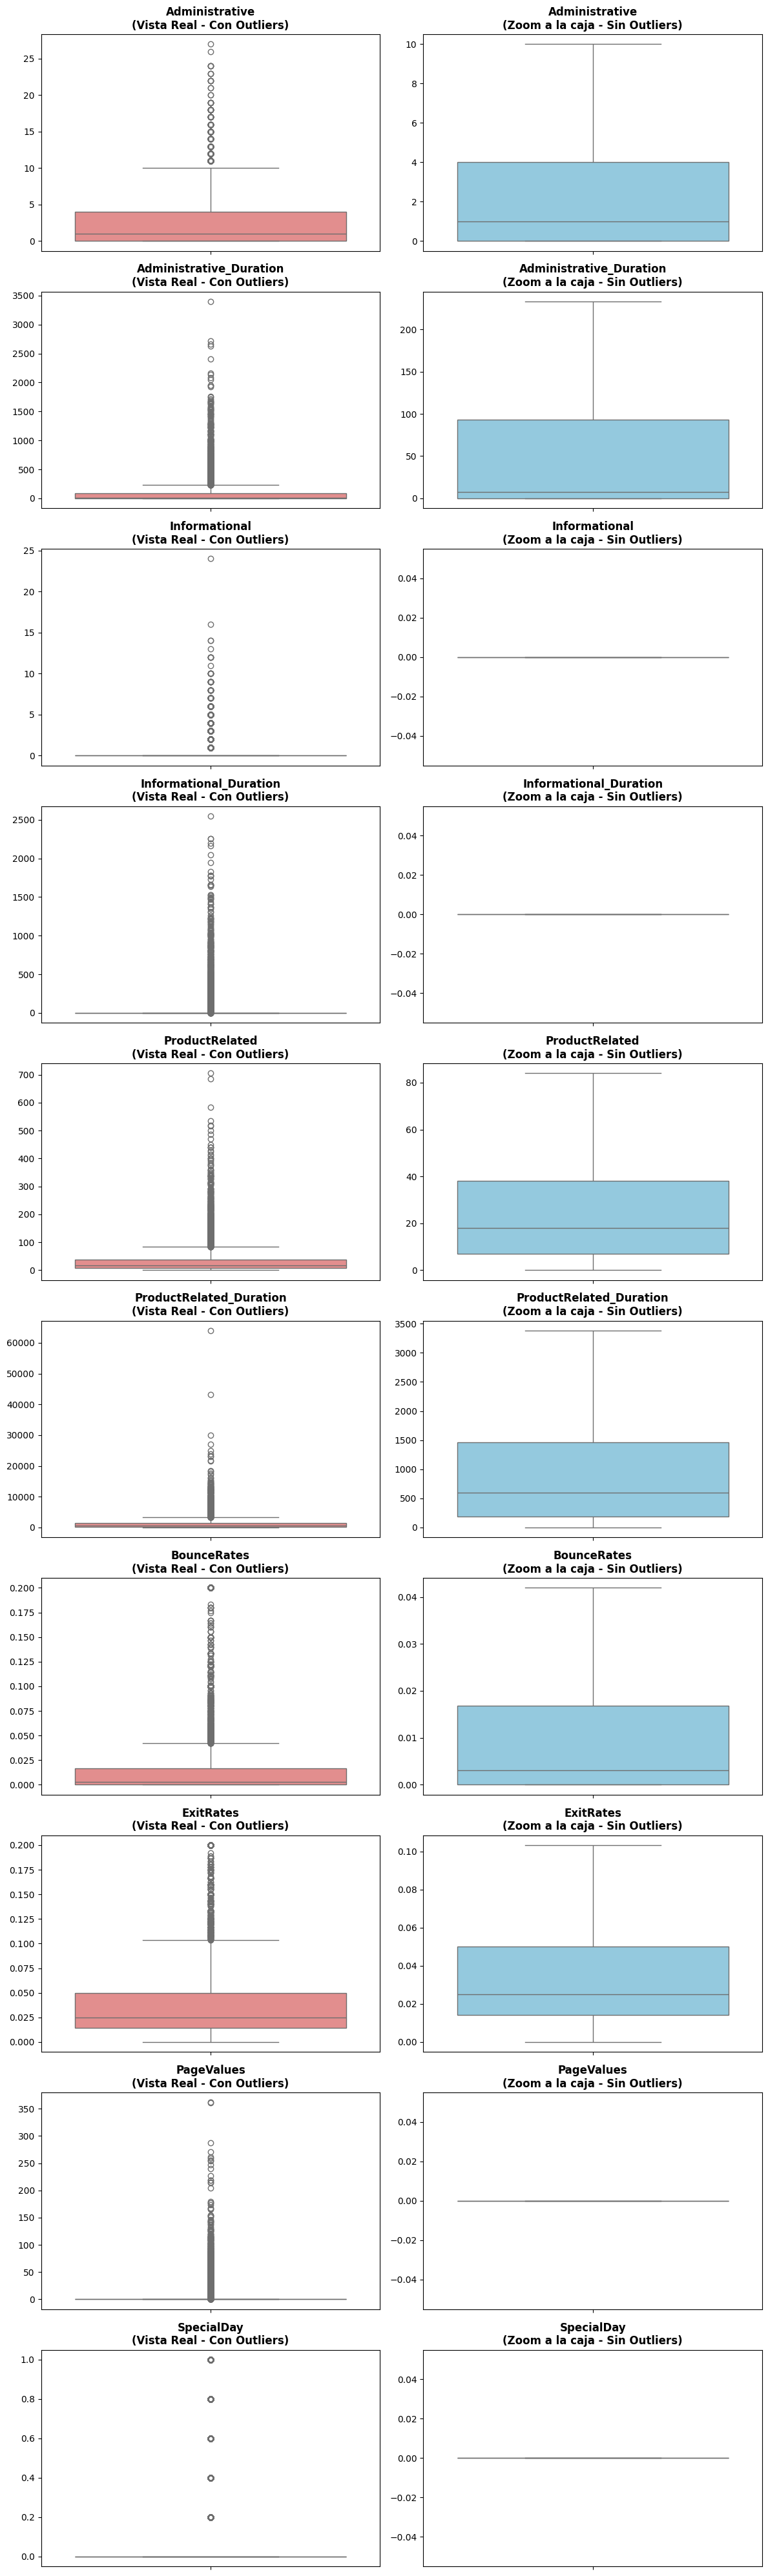

In [8]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
# VALORES ATÍPICOS
print("\n--- COMPARATIVA DE OUTLIERS: CON VS SIN ---")

#Cuadrículas
n_rows = len(numeric_cols)
n_cols = 2 

plt.figure(figsize=(12, n_rows * 4)) 

for i, col in enumerate(numeric_cols):
    # --- GRÁFICO 1: CON OUTLIERS (Izquierda) ---
    plt.subplot(n_rows, n_cols, i * 2 + 1)
    sns.boxplot(y=shop_df[col], color='lightcoral')
    plt.title(f"{col}\n(Vista Real - Con Outliers)", fontweight='bold')
    plt.ylabel('') 

    # --- GRÁFICO 2: SIN OUTLIERS (Derecha) ---
    plt.subplot(n_rows, n_cols, i * 2 + 2)
    sns.boxplot(y=shop_df[col], color='skyblue', showfliers=False)
    plt.title(f"{col}\n(Zoom a la caja - Sin Outliers)", fontweight='bold')
    plt.ylabel('') 

plt.tight_layout()
plt.show()

In [10]:
# ANÁLISIS BIVARIADO: TASA DE CONVERSIÓN

print("\n--- TASA DE CONVERSIÓN POR TIPO DE VISITANTE ---")
# Calculamos el % de compras según el tipo de visitante
conversion_visitor = shop_df.groupby('VisitorType')['Revenue'].mean() * 100
display(conversion_visitor.sort_values(ascending=False))

print("\n--- TASA DE CONVERSIÓN POR MES ---")
# Calculamos el % de compras según el mes del año
conversion_month = shop_df.groupby('Month')['Revenue'].mean() * 100
display(conversion_month.sort_values(ascending=False))


--- TASA DE CONVERSIÓN POR TIPO DE VISITANTE ---


/tmp/ipykernel_57/2321433221.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_visitor = shop_df.groupby('VisitorType')['Revenue'].mean() * 100


VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64


--- TASA DE CONVERSIÓN POR MES ---


/tmp/ipykernel_57/2321433221.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_month = shop_df.groupby('Month')['Revenue'].mean() * 100


Month
Nov     25.350233
Oct     20.947177
Sep     19.196429
Aug     17.551963
Jul     15.277778
Dec     12.507238
May     10.850178
June    10.069444
Mar     10.068170
Feb      1.630435
Name: Revenue, dtype: float64